# Weighted-KNN PM2.5 Forecaster
12-hour ahead PM2.5 prediction using threshold-based weighted KNN with five Euclidean sub-distances.

In [1]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("data/3_scaled/scaled.csv")
TEST_YEAR = 2025
IN_H = 5
OUT_H = 12
SEASONAL_RADIUS = 20  # ±days
DEFAULT_WEIGHTS = np.full(5, 0.2)
DEFAULT_THRESHOLD = 0.5

FEAT_COLS = ["O3", "NO", "NO2", "PM10", "PM2.5", "wind_speed", "temp", "wind_dir_sin", "wind_dir_cos"]
N_FEAT = len(FEAT_COLS)

# Feature index slices for each of the five distance groups
GROUPS: list[list[int]] = [
    [FEAT_COLS.index("wind_speed"), FEAT_COLS.index("wind_dir_sin"), FEAT_COLS.index("wind_dir_cos")],  # d1
    [FEAT_COLS.index("temp")],  # d2
    [FEAT_COLS.index("O3"), FEAT_COLS.index("NO"), FEAT_COLS.index("NO2")],  # d3
    [FEAT_COLS.index("PM10")],  # d4
    [FEAT_COLS.index("PM2.5")],  # d5
]

## Load data

In [2]:
raw = pd.read_csv(DATA_PATH)
raw["datetime"] = pd.to_datetime(raw["date"]) + pd.to_timedelta(raw["time"] - 1, unit="h")
raw = raw.sort_values("datetime").reset_index(drop=True)

print(f"Shape: {raw.shape}")
print(f"Date range: {raw['date'].min()} – {raw['date'].max()}")
print(f"Columns: {raw.columns.tolist()}")
print(f"NaN count: {raw.isna().sum().sum()}")
print(f"day_category values: {sorted(raw['day_category'].unique())}  (0=work, 1=day-off, 2=pre-holiday)")

Shape: (82356, 13)
Date range: 2012-01-01 – 2025-12-30
Columns: ['date', 'time', 'O3', 'NO', 'NO2', 'PM10', 'PM2.5', 'wind_speed', 'temp', 'day_category', 'wind_dir_sin', 'wind_dir_cos', 'datetime']
NaN count: 0
day_category values: [np.int64(0), np.int64(1), np.int64(2)]  (0=work, 1=day-off, 2=pre-holiday)


## Build BlockSets
Each block is a valid, gap-free sequence: 5-hour input window + 12-hour PM2.5 output window.

In [3]:
@dataclass
class BlockSet:
    """Pre-built sliding windows over a time series."""
    X: np.ndarray  # (n, IN_H, N_FEAT)  – input features
    Y: np.ndarray  # (n, OUT_H)          – PM2.5 targets
    dates: np.ndarray  # (n,) str            – date of first input hour
    doys: np.ndarray  # (n,) int            – day-of-year of first input hour
    hours: np.ndarray  # (n,) int            – time (1-24) of first input hour
    day_cats: np.ndarray  # (n,) int            – day_category of first input hour

    def __len__(self) -> int:
        return len(self.X)


def make_blocks(df: pd.DataFrame) -> BlockSet:
    """Slide a (IN_H + OUT_H)-length window over df, keeping only gap-free blocks."""
    features = df[FEAT_COLS].values  # (N, N_FEAT) (82356, 13) [[0.1, 0.3...], [0.45, 0.5...]...]
    pm25 = df["PM2.5"].values # (N,) (82356,) [0.1, 0.3...]
    dt_h = df["datetime"].values.astype("datetime64[h]").astype(np.int64)  # hours since epoch [2024-05-13 14:00:00, ...] -> [476534, 476534, 476536, ...]
    hours = df["time"].values # (82356,) [1, 2, 3, ..., 24, 1, 2, 3, ..., 24, 1, 2, 3, ...   ]
    day_cats = df["day_category"].values # (82356,) [0, 0, 0, 0..., 0, 0, 0, ..., 0, 1, 1, 1...]
    dates = df["date"].values # (82356,) [2012-01-02, 2012-01-02, ...]
    doys = df["datetime"].dt.day_of_year.values # (82356,) [1, 1, ..., 2, 2, ..., 3, ....]

    N = len(df) # 61,335 for train, 5,630 for test
    total = IN_H + OUT_H

    Xs, Ys, ds, doy_arr, h_arr, cat_arr = [], [], [], [], [], []

    for i in range(N - total + 1):
        # All 17 rows must be exactly 1 hour apart (no gaps)
        if not np.all(np.diff(dt_h[i: i + total]) == 1):
            continue
        Xs.append(features[i: i + IN_H])  # (5, N_FEAT)
        Ys.append(pm25[i + IN_H: i + total])  # (12,)
        ds.append(dates[i])
        doy_arr.append(doys[i])
        h_arr.append(hours[i])
        cat_arr.append(day_cats[i])

    return BlockSet(
        X=np.array(Xs, dtype=np.float32), # (n, 5, 13)
        Y=np.array(Ys, dtype=np.float32), # (n, 12)
        dates=np.array(ds), # (n, )
        doys=np.array(doy_arr, dtype=np.int16),
        hours=np.array(h_arr, dtype=np.int8),
        day_cats=np.array(cat_arr, dtype=np.int8),
    )


train_df = raw[raw["datetime"].dt.year < TEST_YEAR]
test_df = raw[raw["datetime"].dt.year == TEST_YEAR]

train_blocks = make_blocks(train_df)
test_blocks = make_blocks(test_df)

print(f"Train blocks: {len(train_blocks):,}")
print(f"Test blocks:  {len(test_blocks):,}")

Train blocks: 61,335
Test blocks:  5,630


In [24]:
print(f"Train (2012–2024) raw min/max PM2.5: {train_df['PM2.5'].min():.2f} / {train_df['PM2.5'].max():.2f}")
print(f"Test  (2025)      raw min/max PM2.5: {test_df['PM2.5'].min():.2f} / {test_df['PM2.5'].max():.2f}")



Train (2012–2024) raw min/max PM2.5: -1.00 / 1.00
Test  (2025)      raw min/max PM2.5: -1.00 / 0.27


## Forecaster components

In [4]:
class WeightedDistance:
    """Aggregated weighted distance D = Σ w_j · d_j over five independent Euclidean sub-distances."""

    def __init__(self, groups: list[list[int]], weights: np.ndarray):
        assert abs(weights.sum() - 1.0) < 1e-6, "weights must sum to 1"
        self.groups = groups
        self.weights = weights

    def __call__(self, x: np.ndarray, Y: np.ndarray) -> np.ndarray:
        """x: (IN_H, N_FEAT), Y: (n_cand, IN_H, N_FEAT) → D: (n_cand,)"""
        D = np.zeros(len(Y), dtype=np.float64)
        for w, idx in zip(self.weights, self.groups):
            diff = x[None, :, idx] - Y[:, :, idx]  # (n_cand, IN_H, |group|)
            d_j = np.sqrt((diff * diff).sum(axis=(1, 2)))
            D += w * d_j
        return D


class NeighborFilter:
    """Produces a boolean mask over train blocks that satisfy all filtering criteria."""

    def __init__(self, train: BlockSet, radius: int = SEASONAL_RADIUS):
        self._hours = train.hours
        self._day_cats = train.day_cats
        self._doys = train.doys.astype(np.int16)
        self._radius = radius

    def mask(self, hour: int, day_cat: int, doy: int) -> np.ndarray:
        hour_ok = self._hours == hour
        cat_ok = self._day_cats == day_cat
        diff = np.abs(self._doys - doy)
        seas_ok = np.minimum(diff, 365 - diff) <= self._radius
        return hour_ok & cat_ok & seas_ok


class WeightedKNNForecaster:
    """Threshold-based weighted KNN forecaster."""

    def __init__(
            self,
            weights: np.ndarray = DEFAULT_WEIGHTS,
            threshold: float = DEFAULT_THRESHOLD,
    ):
        self.threshold = threshold
        self._dist = WeightedDistance(GROUPS, weights)
        self._train: Optional[BlockSet] = None
        self._filter: Optional[NeighborFilter] = None

    def fit(self, train: BlockSet) -> WeightedKNNForecaster:
        self._train = train
        self._filter = NeighborFilter(train)
        return self

    def predict(self, x: np.ndarray, hour: int, day_cat: int, doy: int) -> Optional[np.ndarray]:
        """Returns (OUT_H,) forecast or None when no neighbor qualifies."""
        mask = self._filter.mask(hour, day_cat, doy)
        cand_X = self._train.X[mask]
        if len(cand_X) == 0:
            return None
        D = self._dist(x, cand_X)
        qualified = D <= self.threshold
        if not qualified.any():
            return None
        return self._train.Y[mask][qualified].mean(axis=0)

## Example prediction — inspect one query

In [5]:
forecaster = WeightedKNNForecaster().fit(train_blocks)

i = 0  # first test block
x_q = test_blocks.X[i]
hour_q = int(test_blocks.hours[i])
cat_q = int(test_blocks.day_cats[i])
doy_q = int(test_blocks.doys[i])

# Peek inside the filter step
mask_q = forecaster._filter.mask(hour_q, cat_q, doy_q)
cand_X_q = train_blocks.X[mask_q]
D_q = forecaster._dist(x_q, cand_X_q)
qualified_q = D_q <= DEFAULT_THRESHOLD

print(f"x_q={x_q}")
print(f"Query: date={test_blocks.dates[i]}, hour={hour_q}, day_cat={cat_q}, doy={doy_q}")
print(f"Candidate pool (after filters): {mask_q.sum()}")
print(f"Neighbors within threshold S={DEFAULT_THRESHOLD}: {qualified_q.sum()}")
print(f"Distance stats — min={D_q.min():.4f}, median={np.median(D_q):.4f}, max={D_q.max():.4f}")

pred_q = forecaster.predict(x_q, hour_q, cat_q, doy_q)
print(f"Prediction (first 6 hours): {pred_q[:6] if pred_q is not None else 'no prediction'}")
print(f"Truth      (first 6 hours): {test_blocks.Y[i][:6]}")

x_q=[[-0.4425 -0.9826 -0.8895 -0.8869 -0.9373 -0.635  -0.5262  0.0052  1.    ]
 [-0.3776 -0.984  -0.8883 -0.8972 -0.9373 -0.6058 -0.5262 -0.014   0.9999]
 [-0.4716 -0.9751 -0.8669 -0.9074 -0.8746 -0.5182 -0.4624  0.1201  0.9928]
 [-0.4522 -0.9666 -0.8372 -0.8149 -0.9216 -0.4891 -0.4169  0.0488  0.9988]
 [-0.3679 -0.9706 -0.8788 -0.8355 -0.8903 -0.4453 -0.3804  0.068   0.9977]]
Query: date=2025-01-02, hour=8, day_cat=0, doy=2
Candidate pool (after filters): 119
Neighbors within threshold S=0.5: 5
Distance stats — min=0.3006, median=1.4445, max=2.4254
Prediction (first 6 hours): [-0.88684005 -0.89374    -0.87117994 -0.84860003 -0.82384    -0.83104   ]
Truth      (first 6 hours): [-0.8746 -0.906  -0.9216 -0.9373 -0.8903 -0.8433]


## Evaluator

In [6]:
@dataclass
class EvalResult:
    mu5: float
    sigma5: float
    mu12: float
    sigma12: float
    coverage: float  # percent
    records: list  # (idx, pred|None, y_true) per test window


def evaluate(forecaster: WeightedKNNForecaster, test: BlockSet, pm25_range: float) -> EvalResult:
    """Sliding-window evaluation over all valid test blocks."""
    nmae5, nmae12 = [], []
    records = []
    n_pred = 0

    for i in range(len(test)):
        x = test.X[i]
        y_true = test.Y[i]
        pred = forecaster.predict(x, int(test.hours[i]), int(test.day_cats[i]), int(test.doys[i]))
        records.append((i, pred, y_true))

        if pred is not None:
            n_pred += 1
            nae = np.abs(y_true - pred) / pm25_range * 100.0
            nmae5.append(nae[:5].mean())
            nmae12.append(nae.mean())

    a5 = np.array(nmae5)
    a12 = np.array(nmae12)
    return EvalResult(
        mu5=float(a5.mean()),
        sigma5=float(a5.std()),
        mu12=float(a12.mean()),
        sigma12=float(a12.std()),
        coverage=n_pred / len(test) * 100.0,
        records=records,
    )

## Run evaluation on 2025 test set

In [7]:
pm25_test = test_blocks.Y.ravel()
pm25_range = float(pm25_test.max() - pm25_test.min())
print(f"PM2.5 test range: {pm25_range:.4f}  (max={pm25_test.max():.4f}, min={pm25_test.min():.4f})")

result = evaluate(forecaster, test_blocks, pm25_range)

print(f"\n{'Metric':<12} {'Value':>10}")
print("-" * 24)
print(f"{'μ₅  (%)':<12} {result.mu5:>10.3f}")
print(f"{'σ₅  (%)':<12} {result.sigma5:>10.3f}")
print(f"{'μ₁₂ (%)':<12} {result.mu12:>10.3f}")
print(f"{'σ₁₂ (%)':<12} {result.sigma12:>10.3f}")
print(f"{'C   (%)':<12} {result.coverage:>10.2f}")

PM2.5 test range: 1.2696  (max=0.2696, min=-1.0000)

Metric            Value
------------------------
μ₅  (%)           5.871
σ₅  (%)           4.240
μ₁₂ (%)           6.566
σ₁₂ (%)           4.265
C   (%)           84.71


 Hour      μ (%)      σ (%)
    1      5.284      4.739
    2      5.603      5.166
    3      5.934      5.516
    4      6.171      5.672
    5      6.364      5.751
    6      6.574      5.895
    7      6.769      6.082
    8      6.975      6.222
    9      7.149      6.283
   10      7.214      6.397
   11      7.334      6.624
   12      7.427      6.812


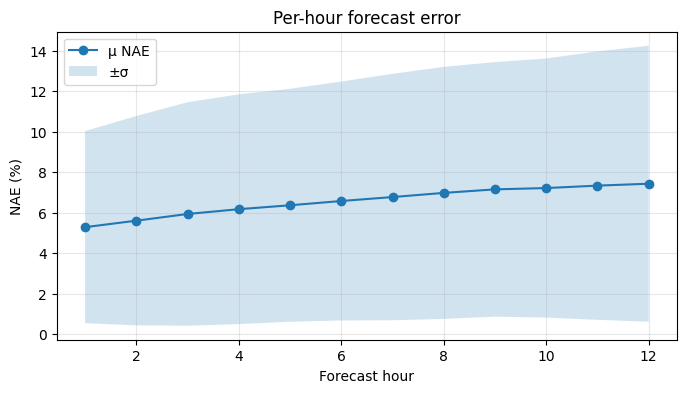

In [8]:
naes = np.array([
    np.abs(y - p) / pm25_range * 100.0
    for _, p, y in result.records if p is not None
])  # (n_predicted, 12)

per_hour_mu = naes.mean(axis=0)
per_hour_sigma = naes.std(axis=0)

print(f"{'Hour':>5} {'μ (%)':>10} {'σ (%)':>10}")
for h, (mu, sd) in enumerate(zip(per_hour_mu, per_hour_sigma), start=1):
    print(f"{h:>5} {mu:>10.3f} {sd:>10.3f}")

plt.figure(figsize=(8, 4))
hours = np.arange(1, OUT_H + 1)
plt.plot(hours, per_hour_mu, "o-", label="μ NAE")
plt.fill_between(hours, per_hour_mu - per_hour_sigma, per_hour_mu + per_hour_sigma, alpha=0.2, label="±σ")
plt.xlabel("Forecast hour")
plt.ylabel("NAE (%)")
plt.title("Per-hour forecast error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



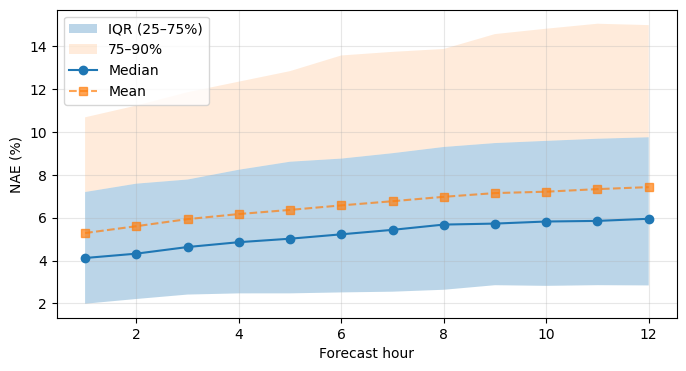

In [9]:
p25 = np.percentile(naes, 25, axis=0)
p50 = np.percentile(naes, 50, axis=0)
p75 = np.percentile(naes, 75, axis=0)
p90 = np.percentile(naes, 90, axis=0)

plt.figure(figsize=(8, 4))
hours = np.arange(1, 13)
plt.fill_between(hours, p25, p75, alpha=0.3, label="IQR (25–75%)")
plt.fill_between(hours, p75, p90, alpha=0.15, label="75–90%")
plt.plot(hours, p50, "o-", label="Median")
plt.plot(hours, naes.mean(axis=0), "s--", label="Mean", alpha=0.7)
plt.xlabel("Forecast hour")
plt.ylabel("NAE (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Predictions vs. truth — example windows

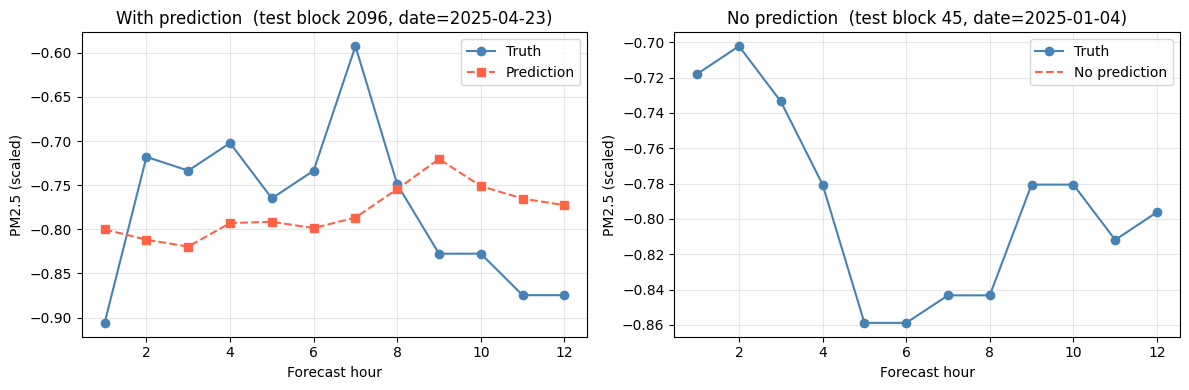

Total test windows: 5630
Predicted: 4769 (84.7%)
No prediction: 861


In [10]:
predicted = [(i, p, y) for i, p, y in result.records if p is not None]
no_pred = [(i, p, y) for i, p, y in result.records if p is None]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Good coverage example
idx, pred, truth = predicted[len(predicted) // 3]  # somewhere in the middle
ax = axes[0]
hours = np.arange(1, OUT_H + 1)
ax.plot(hours, truth, "o-", label="Truth", color="steelblue")
ax.plot(hours, pred, "s--", label="Prediction", color="tomato")
ax.set_title(f"With prediction  (test block {idx}, date={test_blocks.dates[idx]})")
ax.set_xlabel("Forecast hour")
ax.set_ylabel("PM2.5 (scaled)")
ax.legend()
ax.grid(alpha=0.3)

# No-prediction example (or second predicted if none absent)
ax = axes[1]
if no_pred:
    idx2, _, truth2 = no_pred[0]
    ax.plot(hours, truth2, "o-", label="Truth", color="steelblue")
    ax.axhline(y=float("nan"), color="tomato", linestyle="--", label="No prediction")
    ax.set_title(f"No prediction  (test block {idx2}, date={test_blocks.dates[idx2]})")
else:
    idx2, pred2, truth2 = predicted[-1]
    ax.plot(hours, truth2, "o-", label="Truth", color="steelblue")
    ax.plot(hours, pred2, "s--", label="Prediction", color="tomato")
    ax.set_title(f"With prediction  (test block {idx2}, date={test_blocks.dates[idx2]})")
ax.set_xlabel("Forecast hour")
ax.set_ylabel("PM2.5 (scaled)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total test windows: {len(result.records)}")
print(f"Predicted: {len(predicted)} ({result.coverage:.1f}%)")
print(f"No prediction: {len(no_pred)}")

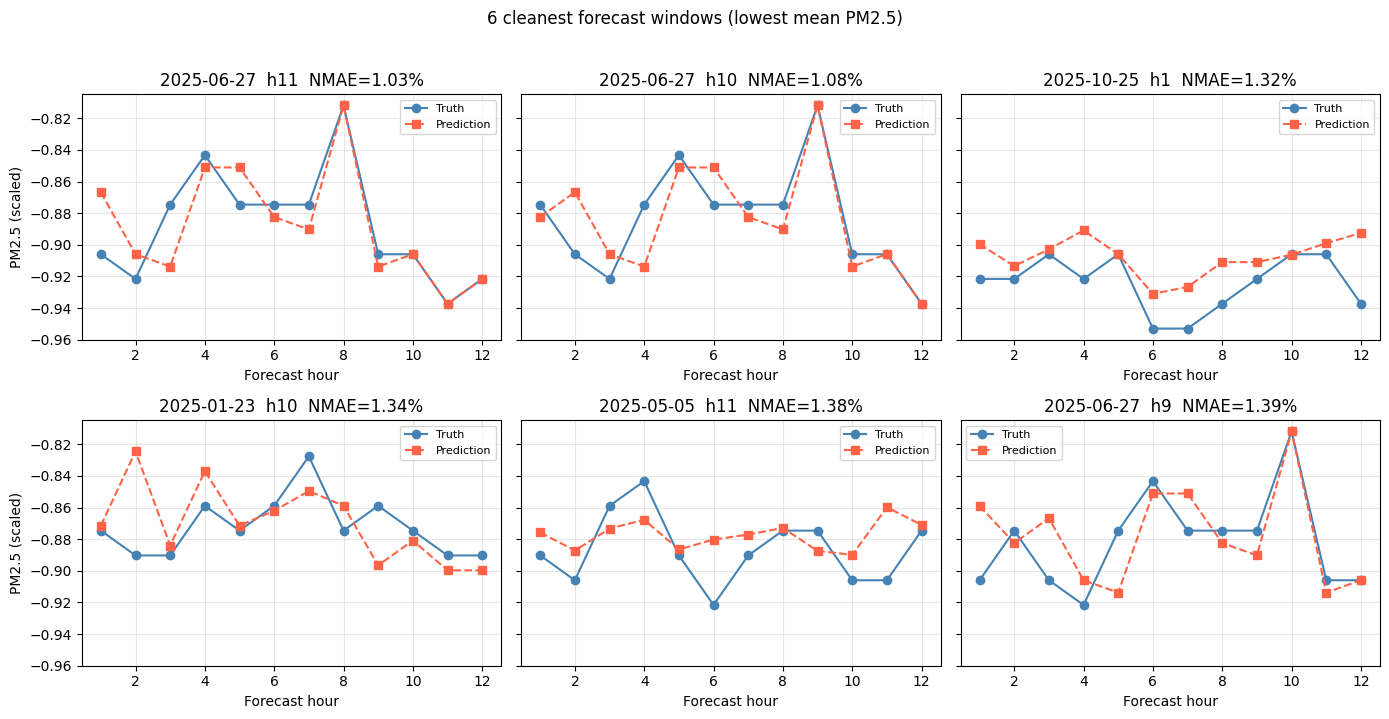

In [11]:
predicted = [(i, p, y) for i, p, y in result.records if p is not None]

# Sort by mean truth PM2.5 — cleanest first
cleanest = sorted(predicted, key=lambda r: r[2].mean())[:6]
best = sorted(predicted, key=lambda r: np.abs(r[1] - r[2]).mean())[:6]


fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
hours = np.arange(1, OUT_H + 1)

for ax, (idx, pred, truth) in zip(axes.flat, best):
    nmae = np.abs(truth - pred).mean() / pm25_range * 100
    ax.plot(hours, truth, "o-", label="Truth", color="steelblue")
    ax.plot(hours, pred, "s--", label="Prediction", color="tomato")
    ax.set_title(f"{test_blocks.dates[idx]}  h{int(test_blocks.hours[idx])}  NMAE={nmae:.2f}%")
    ax.set_xlabel("Forecast hour")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[:, 0]:
    ax.set_ylabel("PM2.5 (scaled)")

plt.suptitle("6 cleanest forecast windows (lowest mean PM2.5)", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
def inspect_query(forecaster, query_blocks, i, top_k_show=5):
    x_q = query_blocks.X[i]
    hour_q = int(query_blocks.hours[i])
    cat_q = int(query_blocks.day_cats[i])
    doy_q = int(query_blocks.doys[i])
    date_q = query_blocks.dates[i]

    in_start = pd.Timestamp(str(date_q)) + pd.Timedelta(hours=hour_q - 1)
    in_end = in_start + pd.Timedelta(hours=IN_H - 1)
    out_start = in_end + pd.Timedelta(hours=1)
    out_end = in_end + pd.Timedelta(hours=OUT_H)

    print(f"=== QUERY ===")
    print(f"Date:        {date_q}")
    print(f"Input:       {in_start}  →  {in_end}   ({IN_H}h)")
    print(f"Forecast:    {out_start}  →  {out_end}  ({OUT_H}h)")
    print(f"Day cat:     {cat_q}   ({'work' if cat_q == 0 else 'day-off' if cat_q == 1 else 'pre-holiday'})")
    print(f"DoY:         {doy_q}   (±{SEASONAL_RADIUS} day seasonal window)")

    mask = forecaster._filter.mask(hour_q, cat_q, doy_q)
    cand_X = forecaster._train.X[mask]
    cand_Y = forecaster._train.Y[mask]
    cand_dates = forecaster._train.dates[mask]
    D = forecaster._dist(x_q, cand_X)
    qual = D <= forecaster.threshold

    pm25_col = FEAT_COLS.index("PM2.5")
    x_pm25 = x_q[:, pm25_col]                                       # (5,)
    truth = query_blocks.Y[i]                                       # (12,)

    print(f"\n=== POOL ===")
    print(f"Candidates after metadata filter: {mask.sum()}")
    print(f"Neighbors within S={forecaster.threshold}: {qual.sum()}")
    print(f"Distance — min: {D.min():.4f}, p25: {np.percentile(D, 25):.4f}, "
          f"median: {np.median(D):.4f}, max: {D.max():.4f}")

    if not qual.any():
        print("\nNo prediction.")
        return None, truth, x_pm25

    pred = cand_Y[qual].mean(axis=0)
    nmae = np.abs(truth - pred).mean() / pm25_range * 100

    # Full 17h trajectory: 5 input + 12 forecast hours
    qual_idx = np.where(qual)[0]
    order = qual_idx[np.argsort(D[qual_idx])][:top_k_show]

    cand_X_pm25 = cand_X[:, :, pm25_col]                             # (n_cand, 5)
    neigh_full = np.concatenate([cand_X_pm25, cand_Y], axis=1)       # (n_cand, 17)
    query_full = np.concatenate([x_pm25, truth])                     # (17,)
    pred_full = np.concatenate([x_pm25, pred])                       # (17,)

    print(f"\n=== TOP {len(order)} CLOSEST NEIGHBORS — full 17h PM2.5 trajectory ===")
    print(f"Hours 1–5 = input window, hours 6–17 = forecast horizon\n")

    hdr = f"{'#':>3}  {'date':<12}  {'D':>6}  " + "  ".join(f"h{h:02d}" for h in range(1, 18))
    print(hdr)
    print("-" * len(hdr))

    print(f"{'Q':>3}  {date_q:<12}  {'-':>6}  " +
          "  ".join(f"{v:>+.2f}" for v in query_full))
    print(f"{'P':>3}  {'(mean)':<12}  {'-':>6}  " +
          "  ".join(f"{v:>+.2f}" for v in pred_full))
    print()
    for rank, j in enumerate(order, 1):
        print(f"{rank:>3}  {cand_dates[j]:<12}  {D[j]:>6.3f}  " +
              "  ".join(f"{v:>+.2f}" for v in neigh_full[j]))

    print(f"\nNMAE (12h): {nmae:.2f}%")
    return pred, truth, x_pm25


# idx_to_inspect = best[0][0]
idx_to_inspect = cleanest[0][0]
inspect_query(forecaster, test_blocks, idx_to_inspect)

=== QUERY ===
Date:        2025-10-13
Input:       2025-10-13 18:00:00  →  2025-10-13 22:00:00   (5h)
Forecast:    2025-10-13 23:00:00  →  2025-10-14 10:00:00  (12h)
Day cat:     0   (work)
DoY:         286   (±20 day seasonal window)

=== POOL ===
Candidates after metadata filter: 182
Neighbors within S=0.5: 10
Distance — min: 0.3082, p25: 1.0471, median: 1.3226, max: 2.1574

=== TOP 5 CLOSEST NEIGHBORS — full 17h PM2.5 trajectory ===
Hours 1–5 = input window, hours 6–17 = forecast horizon

  #  date               D  h01  h02  h03  h04  h05  h06  h07  h08  h09  h10  h11  h12  h13  h14  h15  h16  h17
--------------------------------------------------------------------------------------------------------------
  Q  2025-10-13         -  -0.91  -0.94  -0.91  -0.92  -0.97  -1.00  -0.98  -1.00  -1.00  -0.97  -0.97  -0.95  -0.98  -0.95  -1.00  -1.00  -0.98
  P  (mean)             -  -0.91  -0.94  -0.91  -0.92  -0.97  -0.88  -0.88  -0.88  -0.87  -0.89  -0.87  -0.85  -0.84  -0.81  -0.81  -0.8

(array([-0.88466996, -0.87722   , -0.87967   , -0.87096995, -0.88886994,
        -0.86855   , -0.8521    , -0.84422004, -0.8076    , -0.80698   ,
        -0.81539994, -0.80179006], dtype=float32),
 array([-1.    , -0.9843, -1.    , -1.    , -0.9687, -0.9687, -0.953 ,
        -0.9843, -0.953 , -1.    , -1.    , -0.9843], dtype=float32),
 array([-0.906 , -0.9373, -0.906 , -0.9216, -0.9687], dtype=float32))

In [13]:
configs = {
    "baseline":     [0.20, 0.20, 0.20, 0.20, 0.20],
    "pm25_heavy":   [0.10, 0.10, 0.10, 0.30, 0.40],
    "pm_dominant":  [0.05, 0.05, 0.10, 0.30, 0.50],
    "particles":    [0.10, 0.10, 0.10, 0.35, 0.35],
    "meteo_heavy":  [0.30, 0.30, 0.30, 0.05, 0.05],
    "gases_heavy":  [0.10, 0.10, 0.60, 0.10, 0.10],
}

print(f"{'config':<14} {'μ₅':>7} {'σ₅':>7} {'μ₁₂':>7} {'σ₁₂':>7} {'C':>7}")
print("-" * 56)
for name, w in configs.items():
    f = WeightedKNNForecaster(weights=np.array(w), threshold=0.4).fit(train_blocks)
    r = evaluate(f, test_blocks, pm25_range)
    print(f"{name:<14} {r.mu5:>7.3f} {r.sigma5:>7.3f} {r.mu12:>7.3f} {r.sigma12:>7.3f} {r.coverage:>7.2f}")

config              μ₅      σ₅     μ₁₂     σ₁₂       C
--------------------------------------------------------
baseline         5.609   3.970   6.275   4.197   63.21
pm25_heavy       5.499   3.568   6.336   3.835   90.82
pm_dominant      5.393   3.507   6.380   4.024   96.82
particles        5.569   3.613   6.393   3.864   90.69
meteo_heavy      6.478   5.540   6.861   5.186   38.61
gases_heavy      5.861   4.779   6.350   4.738   60.60


In [14]:
print(max(train_blocks.dates.tolist()), min(test_blocks.dates.tolist()))\

idx_max = test_df["PM2.5"].idxmax()
idx_min = test_df["PM2.5"].idxmin()
print(test_df.loc[idx_max, ["datetime", "PM2.5"]])
print(test_df.loc[idx_min, ["datetime", "PM2.5"]])
print('-------')
print(raw.loc[raw["PM2.5"].idxmax(), ["datetime", "PM2.5"]])
print(raw.loc[raw["PM2.5"].idxmin(), ["datetime", "PM2.5"]])

2024-12-31 2025-01-02
datetime    2025-03-10 00:00:00
PM2.5                    0.2696
Name: 76391, dtype: object
datetime    2025-01-02 05:00:00
PM2.5                      -1.0
Name: 74935, dtype: object
-------
datetime    2017-01-23 00:00:00
PM2.5                       1.0
Name: 37616, dtype: object
datetime    2012-03-05 02:00:00
PM2.5                      -1.0
Name: 1250, dtype: object


## Papildoma analizė ataskaitai

Toliau pateikiamos papildomos diagnostikos ir agreguotos statistikos, kurias galima įtraukti į galutinę ataskaitą.


### Per-hour NMAE: baseline vs. pm_dominant

Destytojo prašymas — paklaidos ir standartiniai nuokrypiai kiekvienai valandai. Skaičiuojame dviem konfigūracijoms lygiagrečiai, kad būtų matoma, kaip kiekviena konfigūracija elgiasi visame prognozės horizonte.


In [15]:
def per_hour_stats(forecaster, test_blocks, pm25_range):
    """Returns per-hour mu and sigma arrays of shape (12,)."""
    res = evaluate(forecaster, test_blocks, pm25_range)
    naes = np.array([
        np.abs(y - p) / pm25_range * 100.0
        for _, p, y in res.records if p is not None
    ])
    return naes.mean(axis=0), naes.std(axis=0), res.coverage, len(naes)


# Two configs to compare
forecaster_base = WeightedKNNForecaster(
    weights=np.array([0.2, 0.2, 0.2, 0.2, 0.2]), threshold=0.5
).fit(train_blocks)

forecaster_pm = WeightedKNNForecaster(
    weights=np.array([0.05, 0.05, 0.10, 0.30, 0.50]), threshold=0.5
).fit(train_blocks)

mu_base, sig_base, c_base, n_base = per_hour_stats(forecaster_base, test_blocks, pm25_range)
mu_pm,   sig_pm,   c_pm,   n_pm   = per_hour_stats(forecaster_pm,   test_blocks, pm25_range)

print(f"Baseline:    C={c_base:.2f}%, N_pred={n_base}")
print(f"pm_dominant: C={c_pm:.2f}%, N_pred={n_pm}")
print()
print(f"{'Val.':>5}  {'μ_base':>8}  {'σ_base':>8}  {'μ_pm':>8}  {'σ_pm':>8}  {'Δμ':>7}")
print("-" * 56)
for h in range(12):
    print(f"{h+1:>5}  {mu_base[h]:>8.3f}  {sig_base[h]:>8.3f}  "
          f"{mu_pm[h]:>8.3f}  {sig_pm[h]:>8.3f}  {mu_pm[h]-mu_base[h]:>+7.3f}")


Baseline:    C=84.71%, N_pred=4769
pm_dominant: C=99.08%, N_pred=5578

 Val.    μ_base    σ_base      μ_pm      σ_pm       Δμ
--------------------------------------------------------
    1     5.284     4.739     5.008     4.031   -0.276
    2     5.603     5.166     5.486     4.483   -0.117
    3     5.934     5.516     5.904     4.898   -0.030
    4     6.171     5.672     6.275     5.283   +0.104
    5     6.364     5.751     6.591     5.588   +0.227
    6     6.574     5.895     6.878     5.861   +0.304
    7     6.769     6.082     7.119     6.152   +0.350
    8     6.975     6.222     7.351     6.393   +0.377
    9     7.149     6.283     7.551     6.542   +0.403
   10     7.214     6.397     7.679     6.639   +0.465
   11     7.334     6.624     7.843     6.795   +0.509
   12     7.427     6.812     8.002     7.017   +0.575


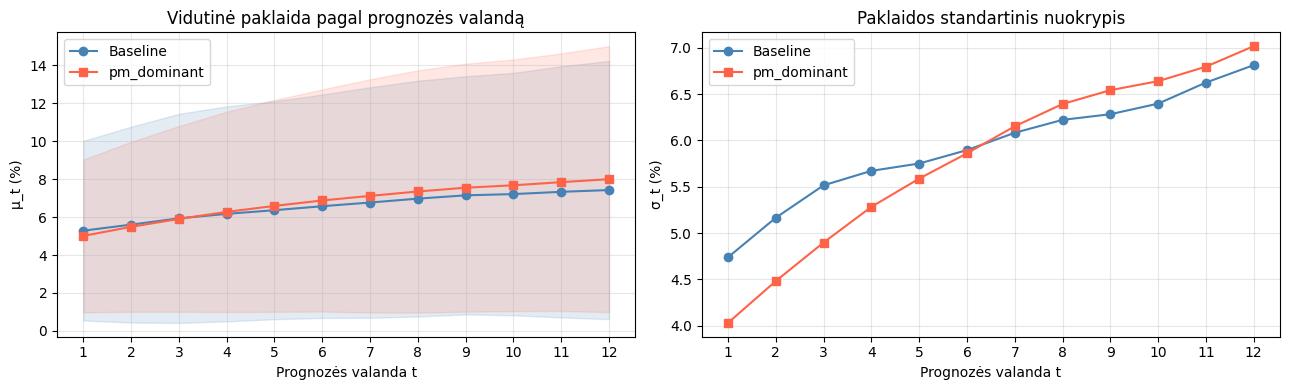

Saved: per_hour_nmae.png


In [16]:
# Save per-hour plot for inclusion in .tex
hours = np.arange(1, 13)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(hours, mu_base, "o-", label="Baseline", color="steelblue")
ax.fill_between(hours, mu_base - sig_base, mu_base + sig_base, alpha=0.15, color="steelblue")
ax.plot(hours, mu_pm, "s-", label="pm_dominant", color="tomato")
ax.fill_between(hours, mu_pm - sig_pm, mu_pm + sig_pm, alpha=0.15, color="tomato")
ax.set_xlabel("Prognozės valanda t")
ax.set_ylabel("μ_t (%)")
ax.set_title("Vidutinė paklaida pagal prognozės valandą")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(hours)

ax = axes[1]
ax.plot(hours, sig_base, "o-", label="Baseline", color="steelblue")
ax.plot(hours, sig_pm, "s-", label="pm_dominant", color="tomato")
ax.set_xlabel("Prognozės valanda t")
ax.set_ylabel("σ_t (%)")
ax.set_title("Paklaidos standartinis nuokrypis")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(hours)

plt.tight_layout()
plt.savefig("per_hour_nmae.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: per_hour_nmae.png")


### NMAE pasiskirstymo percentiliai

Vidurkis ir standartinis nuokrypis nepakankamai gerai apibūdina paklaidos pasiskirstymą, jei jis stipriai asimetriškas. Percentiliai parodo realią paklaidos struktūrą.


In [17]:
# Use baseline result
nmae_per_window_12 = naes.mean(axis=1)  # NMAE_12 for each predicted window
nmae_per_window_5  = naes[:, :5].mean(axis=1)  # NMAE_5

print("NMAE_12 pasiskirstymas (baseline):")
print(f"{'Percentilis':<15} {'Reikšmė (%)':>12}")
print("-" * 28)
for p in [10, 25, 50, 75, 90, 95, 99]:
    v = np.percentile(nmae_per_window_12, p)
    print(f"{'p' + str(p):<15} {v:>12.3f}")
print(f"\n{'Vidurkis':<15} {nmae_per_window_12.mean():>12.3f}")
print(f"{'Maksimumas':<15} {nmae_per_window_12.max():>12.3f}")

print("\n\nNMAE_5 pasiskirstymas (baseline):")
print(f"{'Percentilis':<15} {'Reikšmė (%)':>12}")
print("-" * 28)
for p in [10, 25, 50, 75, 90, 95, 99]:
    v = np.percentile(nmae_per_window_5, p)
    print(f"{'p' + str(p):<15} {v:>12.3f}")


NMAE_12 pasiskirstymas (baseline):
Percentilis      Reikšmė (%)
----------------------------
p10                    3.031
p25                    3.945
p50                    5.402
p75                    7.713
p90                   11.403
p95                   14.680
p99                   22.614

Vidurkis               6.566
Maksimumas            46.563


NMAE_5 pasiskirstymas (baseline):
Percentilis      Reikšmė (%)
----------------------------
p10                    2.287
p25                    3.216
p50                    4.853
p75                    7.104
p90                   10.266
p95                   13.148
p99                   24.367


### NMAE pagal tikrąjį PM2.5 lygį

Patikriname hipotezę, kad modelis sistemingai prasčiau prognozuoja ekstremalius režimus. Suskirsto testinius langus pagal tikrąjį \ce{KD_{2,5}} vidurkį į tris grupes: žemo, vidutinio ir aukšto lygio.


In [18]:
# Per-window stats
truth_means = np.array([y.mean() for _, p, y in result.records if p is not None])
nmae12 = nmae_per_window_12

# Tertile boundaries
q1 = np.percentile(truth_means, 33.33)
q2 = np.percentile(truth_means, 66.67)

bins = {
    "Žemas (švarus oras)":   truth_means < q1,
    "Vidutinis":             (truth_means >= q1) & (truth_means < q2),
    "Aukštas (užterštas)":   truth_means >= q2,
}

print(f"Tertilių ribos (truth mean PM2.5, normalizuotoje skalėje):")
print(f"  q1 = {q1:.3f}")
print(f"  q2 = {q2:.3f}")
print()
print(f"{'Grupė':<25} {'N':>6} {'μ_12 (%)':>10} {'σ_12 (%)':>10} {'p50 (%)':>10}")
print("-" * 65)
for name, mask in bins.items():
    n = mask.sum()
    mu = nmae12[mask].mean()
    sig = nmae12[mask].std()
    p50 = np.percentile(nmae12[mask], 50)
    print(f"{name:<25} {n:>6} {mu:>10.3f} {sig:>10.3f} {p50:>10.3f}")


Tertilių ribos (truth mean PM2.5, normalizuotoje skalėje):
  q1 = -0.882
  q2 = -0.831

Grupė                          N   μ_12 (%)   σ_12 (%)    p50 (%)
-----------------------------------------------------------------
Žemas (švarus oras)         1589      6.403      3.145      5.809
Vidutinis                   1588      4.949      2.464      4.357
Aukštas (užterštas)         1592      8.343      5.725      6.505


### "Ne prognozė" atvejų analizė

Baltosios dėžės principas leidžia modeliui atsisakyti prognozės, kai istoriniame rinkinyje nėra pakankamai panašių situacijų. Tai turėtų būti dažniau ekstremaliais režimais arba retais oro masių tipais.


In [19]:
# Build per-test-block analysis: was it predicted or not?
no_pred_dates = []
pred_dates = []

for i, (_, pred, y) in enumerate(result.records):
    date = test_blocks.dates[i]
    if pred is None:
        no_pred_dates.append(date)
    else:
        pred_dates.append(date)

# By month
months_no_pred = pd.to_datetime(no_pred_dates).month
months_total = pd.to_datetime(np.concatenate([no_pred_dates, pred_dates])).month

month_names = ["Sausis", "Vasaris", "Kovas", "Balandis", "Gegužė", "Birželis",
               "Liepa", "Rugpjūtis", "Rugsėjis", "Spalis", "Lapkritis", "Gruodis"]

print(f"{'Mėnuo':<12} {'Iš viso':>9} {'Ne prog.':>10} {'% ne prog.':>12}")
print("-" * 47)
for m in range(1, 13):
    total = (months_total == m).sum()
    no_p = (months_no_pred == m).sum()
    pct = no_p / total * 100 if total > 0 else 0
    print(f"{month_names[m-1]:<12} {total:>9} {no_p:>10} {pct:>11.2f}%")

print()

# By day_category
print("Pagal dienos kategoriją:")
print(f"{'Kategorija':<25} {'Iš viso':>9} {'Ne prog.':>10} {'% ne prog.':>12}")
print("-" * 60)
for cat, name in [(0, "Darbo diena"), (1, "Poilsio diena"), (2, "Prieššventinė")]:
    mask_total = test_blocks.day_cats == cat
    indices_no_pred = [i for i, (_, p, _) in enumerate(result.records) if p is None]
    cat_no_pred = sum(1 for i in indices_no_pred if test_blocks.day_cats[i] == cat)
    total = mask_total.sum()
    pct = cat_no_pred / total * 100 if total > 0 else 0
    print(f"{name:<25} {total:>9} {cat_no_pred:>10} {pct:>11.2f}%")


Mėnuo          Iš viso   Ne prog.   % ne prog.
-----------------------------------------------
Sausis             512        167       32.62%
Vasaris            515         74       14.37%
Kovas              632        211       33.39%
Balandis           557         98       17.59%
Gegužė             443         41        9.26%
Birželis           442         68       15.38%
Liepa              252         21        8.33%
Rugpjūtis          452         57       12.61%
Rugsėjis           386         16        4.15%
Spalis             491         19        3.87%
Lapkritis          495         36        7.27%
Gruodis            453         53       11.70%

Pagal dienos kategoriją:
Kategorija                  Iš viso   Ne prog.   % ne prog.
------------------------------------------------------------
Darbo diena                    2974        359       12.07%
Poilsio diena                  1693        247       14.59%
Prieššventinė                   963        255       26.48%


### Pareto kreivė — slenksčio $S$ įtaka

Vaizdinis tikslumas--padengimas kompromiso atvaizdavimas. Šis grafikas tinka įtraukti į ataskaitą.


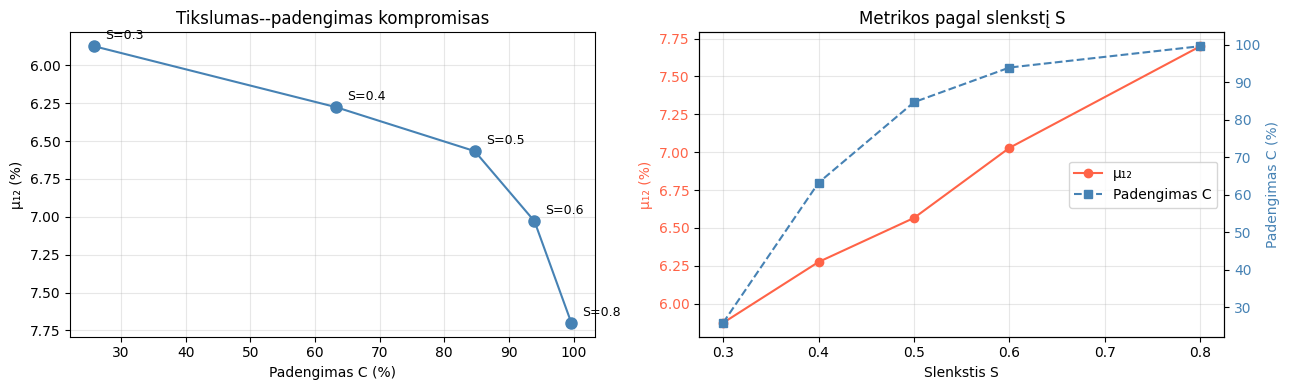

Saved: pareto_curve.png


In [20]:
# S sweep results from earlier experiments
S_values  = [0.30, 0.40, 0.50, 0.60, 0.80]
mu12_vals = [5.873, 6.275, 6.566, 7.029, 7.700]
sig12_vals= [3.760, 4.197, 4.265, 4.794, 4.786]
C_vals    = [25.81, 63.21, 84.71, 93.96, 99.66]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: trade-off curve
ax = axes[0]
ax.plot(C_vals, mu12_vals, "o-", color="steelblue", markersize=8)
for s, c, m in zip(S_values, C_vals, mu12_vals):
    ax.annotate(f"S={s}", (c, m), textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xlabel("Padengimas C (%)")
ax.set_ylabel("μ₁₂ (%)")
ax.set_title("Tikslumas--padengimas kompromisas")
ax.grid(alpha=0.3)
ax.invert_yaxis()  # lower mu (better) up

# Right: both metrics vs S
ax = axes[1]
ax2 = ax.twinx()
l1, = ax.plot(S_values, mu12_vals, "o-", color="tomato", label="μ₁₂")
l2, = ax2.plot(S_values, C_vals, "s--", color="steelblue", label="Padengimas C")
ax.set_xlabel("Slenkstis S")
ax.set_ylabel("μ₁₂ (%)", color="tomato")
ax2.set_ylabel("Padengimas C (%)", color="steelblue")
ax.tick_params(axis='y', labelcolor="tomato")
ax2.tick_params(axis='y', labelcolor="steelblue")
ax.set_title("Metrikos pagal slenkstį S")
ax.grid(alpha=0.3)
ax.legend(handles=[l1, l2], loc="center right")

plt.tight_layout()
plt.savefig("pareto_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: pareto_curve.png")


### NMAE pasiskirstymo histograma

Vizualus paklaidos pasiskirstymo vaizdas — parodo, kad dauguma prognozių yra tikslios, o vidurkį tempia retų didelių paklaidų tail'as.


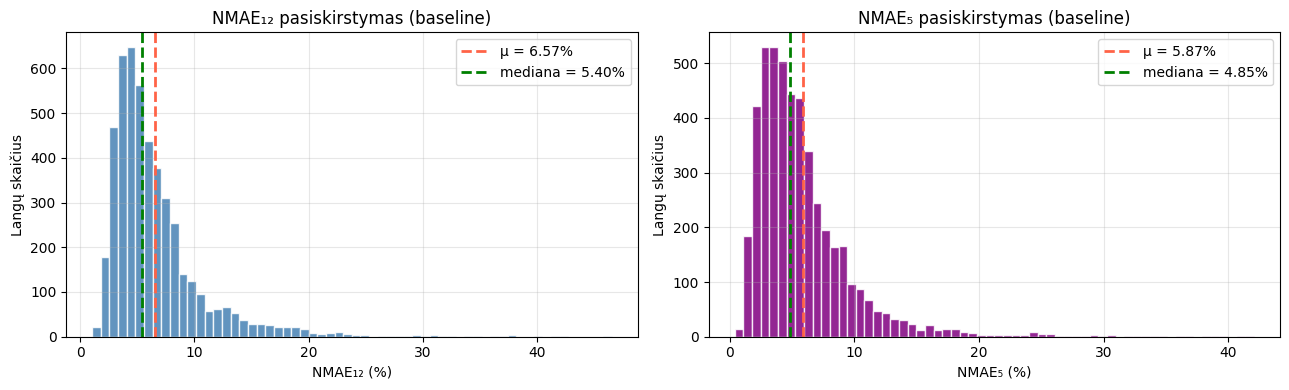

Saved: nmae_histogram.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(nmae_per_window_12, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(nmae_per_window_12.mean(), color="tomato", linestyle="--", linewidth=2, label=f"μ = {nmae_per_window_12.mean():.2f}%")
ax.axvline(np.median(nmae_per_window_12), color="green", linestyle="--", linewidth=2, label=f"mediana = {np.median(nmae_per_window_12):.2f}%")
ax.set_xlabel("NMAE₁₂ (%)")
ax.set_ylabel("Langų skaičius")
ax.set_title("NMAE₁₂ pasiskirstymas (baseline)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(nmae_per_window_5, bins=60, color="purple", edgecolor="white", alpha=0.85)
ax.axvline(nmae_per_window_5.mean(), color="tomato", linestyle="--", linewidth=2, label=f"μ = {nmae_per_window_5.mean():.2f}%")
ax.axvline(np.median(nmae_per_window_5), color="green", linestyle="--", linewidth=2, label=f"mediana = {np.median(nmae_per_window_5):.2f}%")
ax.set_xlabel("NMAE₅ (%)")
ax.set_ylabel("Langų skaičius")
ax.set_title("NMAE₅ pasiskirstymas (baseline)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("nmae_histogram.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: nmae_histogram.png")


### Sėkmingos prognozės pavyzdys

Kaip kontrastas 2025-10-13 analizei, pateikiamas atvejis, kuriame modelis prognozuoja labai tiksliai.


In [22]:
# Best prediction case
best_idx = sorted(
    [(i, p, y) for i, p, y in result.records if p is not None],
    key=lambda r: np.abs(r[1] - r[2]).mean()
)[0][0]

inspect_query(forecaster, test_blocks, best_idx, top_k_show=5)


=== QUERY ===
Date:        2025-06-27
Input:       2025-06-27 10:00:00  →  2025-06-27 14:00:00   (5h)
Forecast:    2025-06-27 15:00:00  →  2025-06-28 02:00:00  (12h)
Day cat:     2   (pre-holiday)
DoY:         178   (±20 day seasonal window)

=== POOL ===
Candidates after metadata filter: 42
Neighbors within S=0.5: 2
Distance — min: 0.4271, p25: 0.7534, median: 0.8902, max: 1.3242

=== TOP 2 CLOSEST NEIGHBORS — full 17h PM2.5 trajectory ===
Hours 1–5 = input window, hours 6–17 = forecast horizon

  #  date               D  h01  h02  h03  h04  h05  h06  h07  h08  h09  h10  h11  h12  h13  h14  h15  h16  h17
--------------------------------------------------------------------------------------------------------------
  Q  2025-06-27         -  -0.76  -0.73  -0.89  -0.91  -0.87  -0.91  -0.92  -0.87  -0.84  -0.87  -0.87  -0.87  -0.81  -0.91  -0.91  -0.94  -0.92
  P  (mean)             -  -0.76  -0.73  -0.89  -0.91  -0.87  -0.87  -0.91  -0.91  -0.85  -0.85  -0.88  -0.89  -0.81  -0.91  -0.91 

(array([-0.86675   , -0.90594995, -0.9138    , -0.85109997, -0.85109997,
        -0.88245   , -0.89030004, -0.8119    , -0.9138    , -0.90595   ,
        -0.93735003, -0.92165   ], dtype=float32),
 array([-0.906 , -0.9216, -0.8746, -0.8433, -0.8746, -0.8746, -0.8746,
        -0.8119, -0.906 , -0.906 , -0.9373, -0.9216], dtype=float32),
 array([-0.7649, -0.7335, -0.8903, -0.906 , -0.8746], dtype=float32))

### Prognozių vs. tikrųjų reikšmių pavyzdžiai

Trys langų grupės (geriausi, vidutiniai, blogiausi) atvaizduojami šalia tikrųjų reikšmių. Saugoma trijuose PNG failuose įtraukimui į ataskaitą.


In [26]:
def plot_examples(items, title, filename):
    """Plot 6 example windows in a 2x3 grid with neighbor count in each title."""
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True, facecolor="white")
    hours = np.arange(1, OUT_H + 1)

    for ax, (idx, pred, truth) in zip(axes.flat, items):
        nmae = np.abs(truth - pred).mean() / pm25_range * 100

        # Recompute neighbor count for this window
        x_q = test_blocks.X[idx]
        hour_q = int(test_blocks.hours[idx])
        cat_q = int(test_blocks.day_cats[idx])
        doy_q = int(test_blocks.doys[idx])

        mask = forecaster._filter.mask(hour_q, cat_q, doy_q)
        cand_X = forecaster._train.X[mask]
        D = forecaster._dist(x_q, cand_X)
        n_neighbors = int((D <= forecaster.threshold).sum())

        ax.set_facecolor("white")
        ax.plot(hours, truth, "o-", label="Tikroji", color="steelblue")
        ax.plot(hours, pred, "s--", label="Prognozė", color="tomato")
        ax.set_title(
            f"{test_blocks.dates[idx]}  h{int(test_blocks.hours[idx]):02d}  "
            f"NMAE={nmae:.2f}%  kaimynų={n_neighbors}",
            color="black",
        )
        ax.set_xlabel("Prognozės valanda", color="black")
        ax.tick_params(colors="black")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc="best")

    for ax in axes[:, 0]:
        ax.set_ylabel("PM2.5 (normalizuota)", color="black")

    plt.suptitle(title, y=1.00, fontsize=12, color="black")
    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {filename}")

In [27]:
# Find the 2025-03-08 h17 case in test_blocks
for i in range(len(test_blocks)):
    if str(test_blocks.dates[i]) == "2025-03-08" and test_blocks.hours[i] == 17:
        idx_problem = i
        break

inspect_query(forecaster, test_blocks, idx_problem)

=== QUERY ===
Date:        2025-03-08
Input:       2025-03-08 16:00:00  →  2025-03-08 20:00:00   (5h)
Forecast:    2025-03-08 21:00:00  →  2025-03-09 08:00:00  (12h)
Day cat:     1   (day-off)
DoY:         67   (±20 day seasonal window)

=== POOL ===
Candidates after metadata filter: 93
Neighbors within S=0.5: 1
Distance — min: 0.4658, p25: 0.9472, median: 1.1869, max: 1.5515

=== TOP 1 CLOSEST NEIGHBORS — full 17h PM2.5 trajectory ===
Hours 1–5 = input window, hours 6–17 = forecast horizon

  #  date               D  h01  h02  h03  h04  h05  h06  h07  h08  h09  h10  h11  h12  h13  h14  h15  h16  h17
--------------------------------------------------------------------------------------------------------------
  Q  2025-03-08         -  -0.83  -0.72  -0.59  -0.56  -0.48  -0.31  -0.40  -0.34  -0.20  -0.45  -0.31  -0.37  -0.36  -0.42  -0.39  -0.45  -0.36
  P  (mean)             -  -0.83  -0.72  -0.59  -0.56  -0.48  -0.73  -0.73  -0.81  -0.84  -0.80  -0.87  -0.87  -0.91  -0.94  -0.86  -0.9

(array([-0.7335, -0.7335, -0.8119, -0.8433, -0.7962, -0.8746, -0.8746,
        -0.906 , -0.9373, -0.8589, -0.906 , -0.8903], dtype=float32),
 array([-0.3103, -0.4044, -0.3417, -0.2006, -0.4514, -0.3103, -0.373 ,
        -0.3574, -0.4201, -0.3887, -0.4514, -0.3574], dtype=float32),
 array([-0.8276, -0.7179, -0.5925, -0.5611, -0.4828], dtype=float32))

In [31]:
from collections import defaultdict

transitions = defaultdict(int)
same_cat_diff_day = defaultdict(int)

for i in range(len(test_blocks)):
    start_date = pd.Timestamp(str(test_blocks.dates[i]))
    start_hour = int(test_blocks.hours[i])
    start_cat = int(test_blocks.day_cats[i])

    end_dt = start_date + pd.Timedelta(hours=start_hour - 1 + 16)
    end_date_only = end_dt.normalize()

    end_cat_row = raw[raw["datetime"].dt.date == end_date_only.date()]
    if len(end_cat_row) == 0:
        continue
    end_cat = int(end_cat_row["day_category"].iloc[0])

    # Ar diena pasikeitė?
    days_diff = (end_date_only - start_date).days

    if start_cat != end_cat:
        transitions[(start_cat, end_cat)] += 1
    elif days_diff > 0:
        # Ta pati kategorija, bet skirtinga diena
        same_cat_diff_day[start_cat] += 1

cat_names = {0: "darbo", 1: "poilsio", 2: "prieššventinė"}

print(f"Iš {len(test_blocks)} testavimo blokų:\n")
print("=== Skirtingų kategorijų perėjimai ===")
print(f"{'Iš':<14} {'→':<5} {'Į':<14} {'N':>6} {'%':>8}")
print("-" * 50)
for (s, e), n in sorted(transitions.items(), key=lambda x: -x[1]):
    pct = n / len(test_blocks) * 100
    print(f"{cat_names[s]:<14} →     {cat_names[e]:<14} {n:>6} {pct:>7.2f}%")

print(f"\nIš viso skirtingų kategorijų: {sum(transitions.values())} "
      f"({sum(transitions.values())/len(test_blocks)*100:.2f}%)")

print("\n=== Ta pati kategorija, bet kita diena ===")
print(f"{'Kategorija':<14} {'N':>6} {'%':>8}")
print("-" * 30)
for cat, n in sorted(same_cat_diff_day.items()):
    pct = n / len(test_blocks) * 100
    print(f"{cat_names[cat]:<14} {n:>6} {pct:>7.2f}%")

print(f"\nIš viso tos pačios kategorijos, bet kitos dienos: "
      f"{sum(same_cat_diff_day.values())} "
      f"({sum(same_cat_diff_day.values())/len(test_blocks)*100:.2f}%)")

Iš 5630 testavimo blokų:

=== Skirtingų kategorijų perėjimai ===
Iš             →     Į                   N        %
--------------------------------------------------
prieššventinė  →     poilsio           647   11.49%
darbo          →     prieššventinė     568   10.09%
poilsio        →     darbo             510    9.06%

Iš viso skirtingų kategorijų: 1725 (30.64%)

=== Ta pati kategorija, bet kita diena ===
Kategorija          N        %
------------------------------
darbo            1470   26.11%
poilsio           557    9.89%

Iš viso tos pačios kategorijos, bet kitos dienos: 2027 (36.00%)


In [29]:
# Compare NMAE for boundary-crossing vs non-crossing blocks
boundary_crossing = []
non_crossing = []

for i, (_, pred, y) in enumerate(result.records):
    if pred is None:
        continue

    start_date = pd.Timestamp(str(test_blocks.dates[i]))
    start_hour = int(test_blocks.hours[i])
    start_cat = int(test_blocks.day_cats[i])

    end_dt = start_date + pd.Timedelta(hours=start_hour - 1 + 16)
    end_date = end_dt.normalize()

    end_cat_row = raw[raw["datetime"].dt.date == end_date.date()]
    if len(end_cat_row) == 0:
        continue
    end_cat = end_cat_row["day_category"].iloc[0]

    nmae = np.abs(y - pred).mean() / pm25_range * 100

    if end_cat != start_cat:
        boundary_crossing.append(nmae)
    else:
        non_crossing.append(nmae)

print(f"Sienos kertantys blokai: N={len(boundary_crossing)}, μ={np.mean(boundary_crossing):.2f}%, σ={np.std(boundary_crossing):.2f}%")
print(f"Nekertantys blokai:      N={len(non_crossing)}, μ={np.mean(non_crossing):.2f}%, σ={np.std(non_crossing):.2f}%")

Sienos kertantys blokai: N=1362, μ=6.20%, σ=4.08%
Nekertantys blokai:      N=3407, μ=6.71%, σ=4.33%


In [30]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(boundary_crossing, non_crossing)
print(f"t-test p-value: {p_value:.4f}")

t-test p-value: 0.0002
